# install lrr() package


Before installing, please download Rtools (https://cran.r-project.org/bin/windows/Rtools)

In [ ]:
if(!require(remotes)) install.packages("remotes")
if (!requireNamespace("lrr", quietly= TRUE)) {
 remotes::install_github("agronomy4future/lrr", force= TRUE)
}
library(remotes)
library(lrr)

# data example

In [2]:
df= data.frame(Cultivar= rep(c("CV1", "CV2", "CV3", "CV4", "CV5",
"CV6", "CV7", "CV8"), each = 4L), Block= rep(c("I", "II", "III", "IV"), 8),
N0= c(608.9, 464.7, 199.3, 930, 623.7, 43.1, 200.3, 207.7, 1243.7, 776.7,
1424.5, 1556.4, 352.2, 1316.7, 377.7, 980.8, 660.9, 1535.5, 1009.2, 1490.8,
692.6, 1273.9, 1010.7, 1105.8, 695, 869, 396, 1147, 883.9, 786.6, 416.2, 1512.6),
N1= c(697.6, 601.9, 1063.4, 440.6, 313, 109.9, 119.9, 281.3, 3463.1, 1364.8, 1991.9,
1264, 1837.9, 1382.5, 1160.5, 248.9, 1679.7, 1704.4, 1631.7, 1065.9, 2466.4, 1324.5,
3790.1, NA, 1735, 872.3, 2314, NA, 2001.4, 1700.4, 2521.4, NA))

print(head (df, 5))

  Cultivar Block    N0     N1
1      CV1     I 608.9  697.6
2      CV1    II 464.7  601.9
3      CV1   III 199.3 1063.4
4      CV1    IV 930.0  440.6
5      CV2     I 623.7  313.0


# run code

In [3]:
output= lrr(data= df, trt= N0, ctrl= N1, group = c("Cultivar"))

print(output)

  Cultivar n_T n_C n_LRR          LRR     LRR_L     LRR_U    Cohen_d   Hedges_g
1      CV1   4   4     4 -0.330514832 -1.924442 1.2634125 -0.5269730 -0.4582374
2      CV2   4   4     4 -0.009187594 -1.209322 1.1909472  0.3279905  0.2852091
3      CV3   4   4     4 -0.428739063 -1.243705 0.3862267 -1.0188530 -0.8859592
4      CV4   4   4     4 -0.363033297 -2.487070 1.7610031 -0.6920945 -0.6018213
5      CV5   4   4     4 -0.295524032 -1.154888 0.5638399 -0.9486484 -0.8249117
6      CV6   3   3     3 -0.876921152 -2.680809 0.9269668 -1.7118456 -1.3694765
7      CV7   3   3     3 -0.894653273 -3.083024 1.2937177 -1.8273893 -1.4619115
8      CV8   3   3     3 -1.129853628 -2.575724 0.3160167 -4.0361639 -3.2289311


In [4]:
output1= lrr(data= df, trt= N0, ctrl= N1, group = c("Cultivar", "Block"))

print(output1)
## Note: If the Block is included, the CI is not calculated because there are
         # no replicates, but this LRR values can be used for geom_jitter

   Cultivar Block n_T n_C n_LRR          LRR LRR_L LRR_U Cohen_d Hedges_g
1       CV1     I   1   1     1 -0.135991822    NA    NA      NA       NA
2       CV2     I   1   1     1  0.689466293    NA    NA      NA       NA
3       CV3     I   1   1     1 -1.024073334    NA    NA      NA       NA
4       CV4     I   1   1     1 -1.652179698    NA    NA      NA       NA
5       CV5     I   1   1     1 -0.932767943    NA    NA      NA       NA
6       CV6     I   1   1     1 -1.270062245    NA    NA      NA       NA
7       CV7     I   1   1     1 -0.914850847    NA    NA      NA       NA
8       CV8     I   1   1     1 -0.817258281    NA    NA      NA       NA
9       CV1    II   1   1     1 -0.258699282    NA    NA      NA       NA
10      CV2    II   1   1     1 -0.936047864    NA    NA      NA       NA
11      CV3    II   1   1     1 -0.563709001    NA    NA      NA       NA
12      CV4    II   1   1     1 -0.048764848    NA    NA      NA       NA
13      CV5    II   1   1     1 -0.104

# visualization

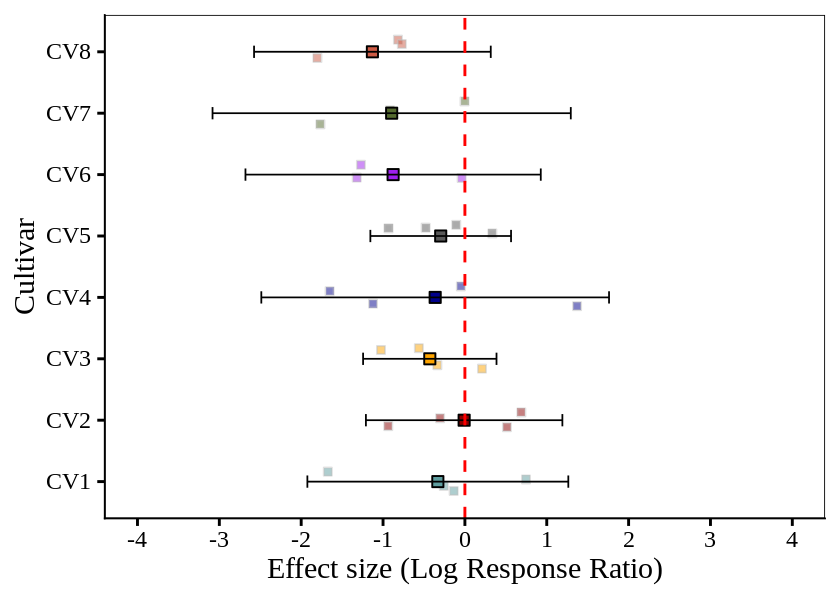

In [18]:
if(!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)

LRR= ggplot() +

  geom_jitter(data= output1, aes(x= Cultivar, y= LRR, fill= Cultivar, shape= Cultivar),
              width=0.2, alpha=0.5, size=2, color="grey75") +

  geom_point(data=output, aes(x=Cultivar, y=LRR, fill=Cultivar, shape=Cultivar),
                            color= "black", size= 3) +
  geom_errorbar(data=output, aes(x=Cultivar, ymin= LRR_L, ymax= LRR_U),
               width=0.2, linewidth=0.5, color="black") +
  geom_hline(yintercept=0, linetype="dashed", color= "red") +
  scale_fill_manual(values = c("cadetblue", "darkred", "orange", "darkblue", "grey35",
                               "purple", "darkolivegreen", "coral3")) +
  scale_shape_manual(values = rep(22, 8)) +
  scale_y_continuous(breaks = seq(-4, 4, 1), limits = c(-4, 4)) +
  coord_flip () +
  labs(x="Cultivar", y="Effect size (Log Response Ratio)") +
  theme_classic(base_size= 18, base_family = "serif") +
  theme(legend.position="none",
        legend.title=element_blank(),
        legend.key=element_rect(color="white", fill=alpha(0.5)),
        legend.text=element_text(family="serif", face="plain",
                                 size=15, color="black"),
        legend.background= element_rect(fill=alpha(0.5)),
        strip.background=element_rect(color="white",
                                      linewidth=0.5,linetype="solid"),
        panel.border= element_rect(color="black", fill=NA, linewidth=0.5),
        axis.line= element_line(linewidth= 0.5, colour= "black"))

options(repr.plot.width=7, repr.plot.height=5)
print(LRR)

ggsave("LRR.png", plot=LRR, width=7, height= 5, dpi= 300)